# Model evaluation

This notebook analyzes model-development experiments generated with:

```bash
python -m scripts.run_experiments --experiment <experiment_name>
```


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## Setup


In [2]:
def find_project_root() -> Path:
    cwd = Path.cwd().resolve()

    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Run the notebook from inside the repository."
    )


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "results"

PROJECT_ROOT, RESULTS_DIR


(PosixPath('/home/adrian/Proyectos/gas-sensor-drift-classification'),
 PosixPath('/home/adrian/Proyectos/gas-sensor-drift-classification/results'))

## Analysis helpers

In [3]:
REQUIRED_COLUMNS = {
    "model",
    "protocol",
    "split",
    "macro_f1",
    "accuracy",
}


def load_experiment(filename: str) -> pd.DataFrame:
    path = RESULTS_DIR / filename
    results = pd.read_csv(path)

    missing_columns = REQUIRED_COLUMNS - set(results.columns)
    if missing_columns:
        raise ValueError(
            f"{filename} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    print(f"Loaded: {path.name}")
    print(f"Rows: {len(results):,}")
    print(f"Models: {results['model'].nunique()}")
    print(f"Protocols: {sorted(results['protocol'].unique())}")

    return results


def class_f1_columns(df: pd.DataFrame) -> list[str]:
    columns = [
        column
        for column in df.columns
        if column.startswith("f1_class_")
    ]

    return sorted(
        columns,
        key=lambda column: int(
            column.rsplit("_", maxsplit=1)[1]
        ),
    )


def protocol_results(
    df: pd.DataFrame,
    protocol: str,
) -> pd.DataFrame:
    return df.loc[df["protocol"] == protocol].copy()


In [4]:
def summarize_random_cv(
    results: pd.DataFrame,
) -> pd.DataFrame:
    random_results = protocol_results(
        results,
        "random_stratified",
    )

    return (
        random_results
        .groupby("model")[["macro_f1", "accuracy"]]
        .agg(["mean", "std"])
    )


def summarize_random_class_f1(
    results: pd.DataFrame,
) -> pd.DataFrame:
    random_results = protocol_results(
        results,
        "random_stratified",
    )

    class_columns = class_f1_columns(results)

    return (
        random_results
        .groupby("model")[class_columns]
        .mean()
    )


def get_temporal_results(
    results: pd.DataFrame,
) -> pd.DataFrame:
    temporal = protocol_results(
        results,
        "expanding_window",
    )

    return temporal.sort_values(
        ["model", "validation_batch"]
    )


In [5]:
def temporal_summary(
    results: pd.DataFrame,
) -> pd.DataFrame:
    temporal = get_temporal_results(results)

    return (
        temporal
        .groupby("model")["macro_f1"]
        .agg(
            mean="mean",
            std="std",
            minimum="min",
            maximum="max",
        )
        .sort_values("mean", ascending=False)
    )


def random_vs_temporal_summary(
    results: pd.DataFrame,
) -> pd.DataFrame:
    random_results = protocol_results(
        results,
        "random_stratified",
    )
    temporal = get_temporal_results(results)

    random_means = (
        random_results
        .groupby("model", as_index=False)["macro_f1"]
        .mean()
        .rename(
            columns={
                "macro_f1": "random_cv_macro_f1_mean"
            }
        )
    )

    temporal_stats = (
        temporal
        .groupby("model")["macro_f1"]
        .agg(
            temporal_macro_f1_mean="mean",
            temporal_macro_f1_std="std",
            temporal_macro_f1_min="min",
            temporal_macro_f1_max="max",
        )
        .reset_index()
    )

    return random_means.merge(
        temporal_stats,
        on="model",
        how="outer",
    )


In [6]:
def plot_temporal_macro_f1(
    results: pd.DataFrame,
    title: str,
) -> None:
    temporal = get_temporal_results(results)

    fig, ax = plt.subplots(figsize=(9, 5))

    for model_name, model_results in temporal.groupby("model"):
        ax.plot(
            model_results["validation_batch"],
            model_results["macro_f1"],
            marker="o",
            label=model_name,
        )

    ax.set_xlabel("Validation batch")
    ax.set_ylabel("Macro-F1")
    ax.set_title(title)
    ax.set_ylim(0.0, 1.05)
    ax.grid(alpha=0.25)
    ax.legend()

    plt.show()


def plot_temporal_class_f1(
    results: pd.DataFrame,
) -> None:
    temporal = get_temporal_results(results)
    class_columns = class_f1_columns(results)

    for model_name, model_results in temporal.groupby("model"):
        fig, ax = plt.subplots(figsize=(10, 5))

        for column in class_columns:
            class_label = column.rsplit("_", maxsplit=1)[1]

            ax.plot(
                model_results["validation_batch"],
                model_results[column],
                marker="o",
                label=f"class {class_label}",
            )

        ax.set_xlabel("Validation batch")
        ax.set_ylabel("F1")
        ax.set_title(
            f"Per-class temporal F1 ({model_name})"
        )
        ax.set_ylim(0.0, 1.05)
        ax.grid(alpha=0.25)
        ax.legend(ncol=3)

        plt.show()


In [7]:
def metric_gap_table(
    results: pd.DataFrame,
) -> pd.DataFrame:
    temporal = get_temporal_results(results)

    gap = temporal[
        [
            "model",
            "validation_batch",
            "macro_f1",
            "accuracy",
        ]
    ].copy()

    gap["accuracy_minus_macro_f1"] = (
        gap["accuracy"] - gap["macro_f1"]
    )

    return gap.sort_values(
        ["model", "accuracy_minus_macro_f1"],
        ascending=[True, False],
    )


# Experiment 1: Logistic Regression regularization

`C=1.0` is the original untuned baseline. The remaining configurations test whether stronger or weaker L2 regularization improves generalization to future acquisition batches.

In [8]:
logreg_results = load_experiment(
    "logreg_tuning.csv"
)

logreg_results.head()


Loaded: logreg_tuning.csv
Rows: 52
Models: 4
Protocols: ['expanding_window', 'random_stratified']


,model,protocol,split,train_batches,validation_batches,validation_batch,n_train,n_validation,macro_f1,accuracy,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
0,logreg_C0.01,random_stratified,random_fold_1,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.969046,0.972842,0.972903,0.992465,0.977995,0.930582,0.983471,0.956863
1,logreg_C0.01,random_stratified,random_fold_2,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.978142,0.980601,0.976923,0.996778,0.985437,0.951128,0.986584,0.972000
2,logreg_C0.01,random_stratified,random_fold_3,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.974493,0.977207,0.975547,0.990333,0.970588,0.955720,0.984359,0.970414
3,logreg_C0.01,random_stratified,random_fold_4,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.967528,0.971872,0.969309,0.989270,0.962594,0.950943,0.985477,0.947573
4,logreg_C0.01,random_stratified,random_fold_5,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.970192,0.973327,0.974026,0.988260,0.965517,0.947368,0.979381,0.966601


## Random stratified evaluation

This remains a conventional IID-like reference. Because acquisition batches are mixed across folds, it should not be treated as a deployment-like estimate under temporal distribution shift.


In [9]:
random_logreg = protocol_results(
    logreg_results,
    "random_stratified",
)

random_logreg[
    ["model", "split", "macro_f1", "accuracy"]
].sort_values(["model", "split"])


,model,split,macro_f1,accuracy
0,logreg_C0.01,random_fold_1,0.969046,0.972842
1,logreg_C0.01,random_fold_2,0.978142,0.980601
2,logreg_C0.01,random_fold_3,0.974493,0.977207
3,logreg_C0.01,random_fold_4,0.967528,0.971872
4,logreg_C0.01,random_fold_5,0.970192,0.973327
13,logreg_C0.1,random_fold_1,0.986597,0.987876
14,logreg_C0.1,random_fold_2,0.986702,0.988361
15,logreg_C0.1,random_fold_3,0.985465,0.986906
16,logreg_C0.1,random_fold_4,0.983282,0.983996
17,logreg_C0.1,random_fold_5,0.982976,0.984481


In [10]:
summarize_random_cv(logreg_results)


macro_f1            accuracy          
                  mean       std      mean       std
model                                               
logreg_C0.01  0.971880  0.004355  0.975170  0.003652
logreg_C0.1   0.985004  0.001783  0.986324  0.001982
logreg_C1     0.990061  0.003965  0.991077  0.003474
logreg_C10    0.991382  0.002665  0.992241  0.002169

### Mean per-class F1 under random stratified CV


In [11]:
summarize_random_class_f1(logreg_results)


,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
model,,,,,,
logreg_C0.01,0.973742,0.991421,0.972426,0.947148,0.983855,0.962690
logreg_C0.1,0.985378,0.991855,0.975996,0.981472,0.988610,0.986715
logreg_C1,0.993623,0.995065,0.978194,0.992505,0.989851,0.991129
logreg_C10,0.994657,0.995917,0.979670,0.993223,0.990493,0.994335


## Expanding-window temporal evaluation

For every validation batch, training is restricted to earlier batches. The individual batch results remain the primary evidence because batch sizes and class composition differ substantially.


In [12]:
logreg_temporal = get_temporal_results(
    logreg_results
)

temporal_columns = [
    "model",
    "validation_batch",
    "n_validation",
    "macro_f1",
    "accuracy",
    *class_f1_columns(logreg_results),
]

logreg_temporal[temporal_columns]


,model,validation_batch,n_validation,macro_f1,accuracy,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
5,logreg_C0.01,2.0,1244,0.632895,0.825563,0.590818,0.977376,0.990099,0.000000,0.916497,0.322581
6,logreg_C0.01,3.0,1586,0.783148,0.800126,0.388119,0.998981,0.981567,0.580282,0.966790,NaN
7,logreg_C0.01,4.0,161,0.791339,0.795031,0.816667,0.926829,1.000000,0.723404,0.489796,NaN
8,logreg_C0.01,5.0,197,0.980111,0.979695,0.982456,1.000000,0.974359,0.967742,0.976000,NaN
9,logreg_C0.01,6.0,2300,0.667291,0.773043,0.974104,0.999130,0.957346,0.103020,0.970149,0.000000
10,logreg_C0.01,7.0,3613,0.818254,0.821478,0.987072,0.788783,0.944282,0.429926,0.820915,0.938547
11,logreg_C0.01,8.0,294,0.760593,0.690476,0.952381,0.947368,0.805970,0.911765,0.628319,0.317757
12,logreg_C0.01,9.0,470,0.753997,0.770213,0.968254,1.000000,1.000000,0.589641,0.946667,0.019417
18,logreg_C0.1,2.0,1244,0.698311,0.846463,0.623482,0.968326,0.990099,0.000000,0.941294,0.666667
19,logreg_C0.1,3.0,1586,0.795698,0.814628,0.394904,0.996948,0.986239,0.618919,0.981481,NaN


### Temporal macro-F1 by batch


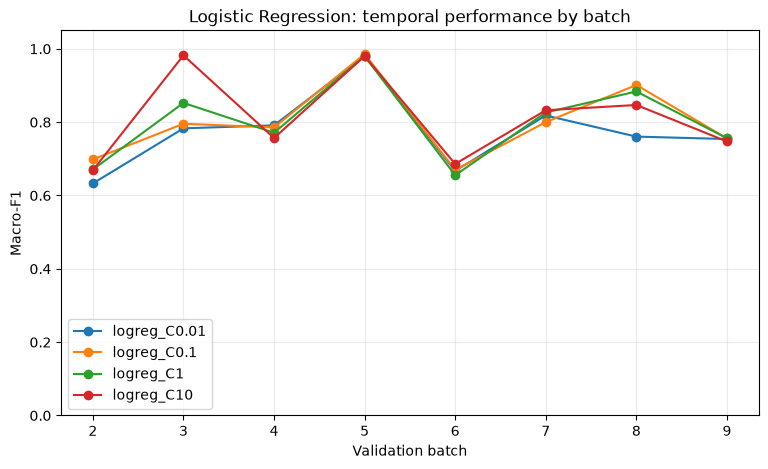

In [13]:
plot_temporal_macro_f1(
    logreg_results,
    title="Logistic Regression: temporal performance by batch",
)


### Descriptive temporal summary

The unweighted mean treats every acquisition period equally. It is useful as a compact secondary summary, but it does not replace the batch-by-batch results above.


In [14]:
temporal_summary(logreg_results)


,mean,std,minimum,maximum
model,,,,
logreg_C10,0.812587,0.120967,0.668881,0.982189
logreg_C1,0.799547,0.109047,0.655378,0.980111
logreg_C0.1,0.799046,0.103019,0.669810,0.985816
logreg_C0.01,0.773454,0.104676,0.632895,0.980111


### Accuracy vs macro-F1

A large difference can reveal uneven class-level performance in batches with imbalanced class composition.


In [15]:
metric_gap_table(logreg_results)


,model,validation_batch,macro_f1,accuracy,accuracy_minus_macro_f1
5,logreg_C0.01,2.0,0.632895,0.825563,0.192668
9,logreg_C0.01,6.0,0.667291,0.773043,0.105752
6,logreg_C0.01,3.0,0.783148,0.800126,0.016979
12,logreg_C0.01,9.0,0.753997,0.770213,0.016216
7,logreg_C0.01,4.0,0.791339,0.795031,0.003692
10,logreg_C0.01,7.0,0.818254,0.821478,0.003224
8,logreg_C0.01,5.0,0.980111,0.979695,-0.000416
11,logreg_C0.01,8.0,0.760593,0.690476,-0.070117
18,logreg_C0.1,2.0,0.698311,0.846463,0.148152
22,logreg_C0.1,6.0,0.669810,0.780435,0.110625


## Per-class temporal performance

Absent classes remain `NaN`; this is intentionally different from assigning F1 = 0.


In [16]:
logreg_temporal[
    [
        "model",
        "validation_batch",
        *class_f1_columns(logreg_results),
    ]
]


,model,validation_batch,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
5,logreg_C0.01,2.0,0.590818,0.977376,0.990099,0.000000,0.916497,0.322581
6,logreg_C0.01,3.0,0.388119,0.998981,0.981567,0.580282,0.966790,NaN
7,logreg_C0.01,4.0,0.816667,0.926829,1.000000,0.723404,0.489796,NaN
8,logreg_C0.01,5.0,0.982456,1.000000,0.974359,0.967742,0.976000,NaN
9,logreg_C0.01,6.0,0.974104,0.999130,0.957346,0.103020,0.970149,0.000000
10,logreg_C0.01,7.0,0.987072,0.788783,0.944282,0.429926,0.820915,0.938547
11,logreg_C0.01,8.0,0.952381,0.947368,0.805970,0.911765,0.628319,0.317757
12,logreg_C0.01,9.0,0.968254,1.000000,1.000000,0.589641,0.946667,0.019417
18,logreg_C0.1,2.0,0.623482,0.968326,0.990099,0.000000,0.941294,0.666667
19,logreg_C0.1,3.0,0.394904,0.996948,0.986239,0.618919,0.981481,NaN


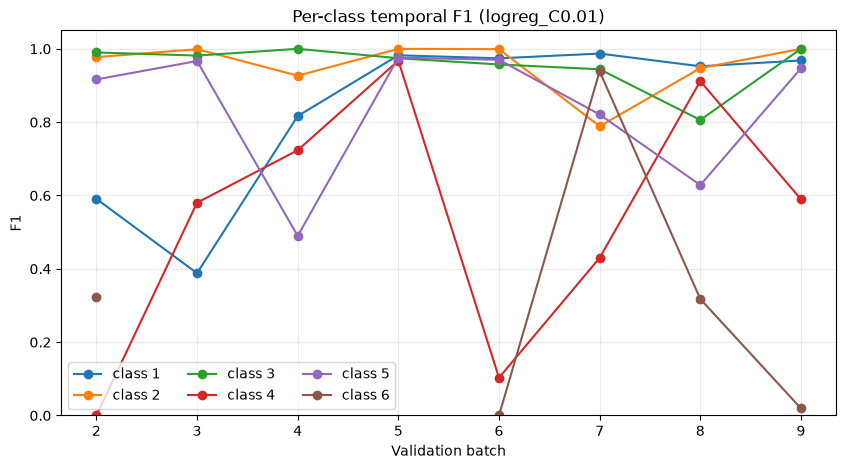

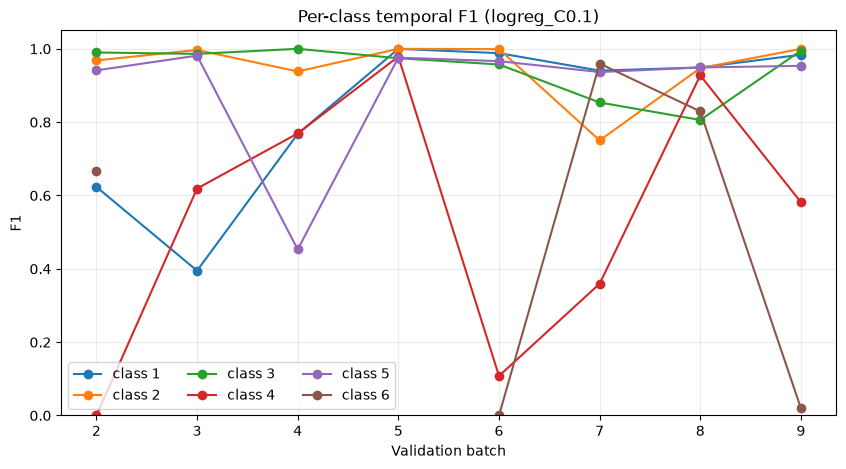

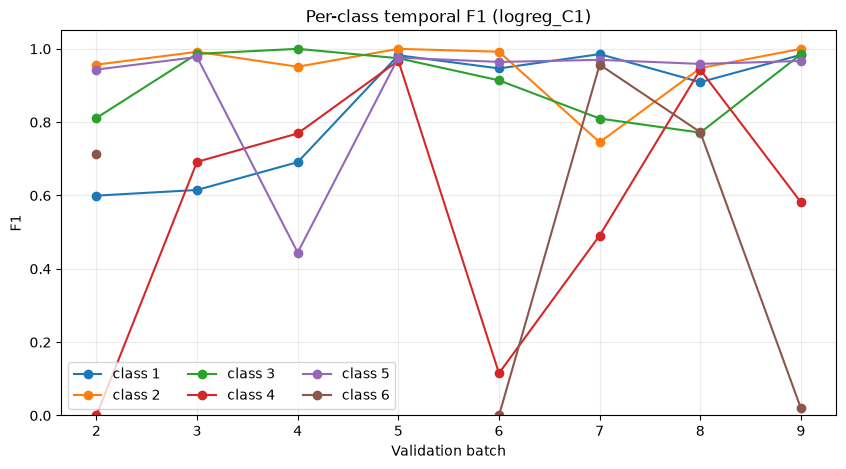

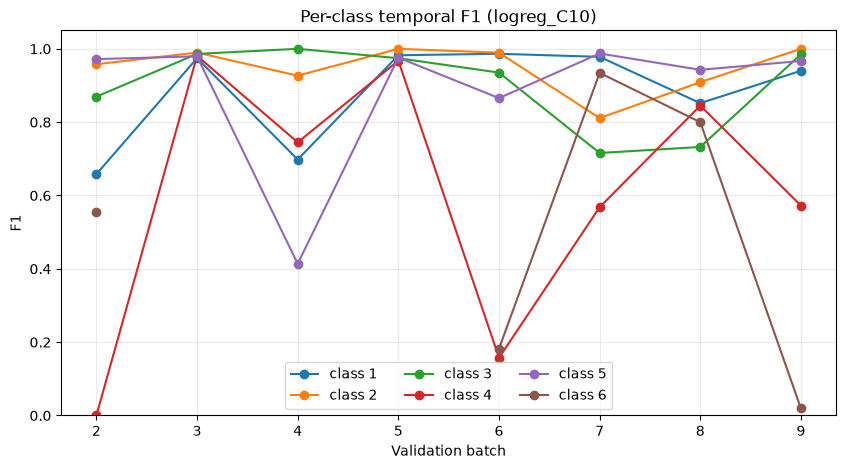

In [17]:
plot_temporal_class_f1(
    logreg_results
)


## Random vs temporal evaluation


In [18]:
random_vs_temporal_summary(
    logreg_results
)


,model,random_cv_macro_f1_mean,temporal_macro_f1_mean,temporal_macro_f1_std,temporal_macro_f1_min,temporal_macro_f1_max
0,logreg_C0.01,0.971880,0.773454,0.104676,0.632895,0.980111
1,logreg_C0.1,0.985004,0.799046,0.103019,0.669810,0.985816
2,logreg_C1,0.990061,0.799547,0.109047,0.655378,0.980111
3,logreg_C10,0.991382,0.812587,0.120967,0.668881,0.982189


Increasing C generally improves Logistic Regression performance, although the effect is substantially smaller than the variation observed across acquisition batches. C=10 achieves the highest mean temporal macro-F1 (0.813), compared with 0.800 for the original C=1 baseline, while maintaining a similar worst-batch performance. However, it also exhibits greater variability across batches and does not consistently outperform the other configurations in every period. We therefore select C=10 as the Logistic Regression configuration for subsequent model comparison, while noting that regularization strength has a relatively modest effect compared with batch-dependent distribution shift.

Random stratified cross-validation consistently produces substantially higher performance estimates than the expanding-window evaluation. For all Logistic Regression configurations, random CV yields macro-F1 scores above 0.97, whereas mean temporal performance ranges from approximately 0.77 to 0.81 and varies considerably across acquisition batches. This large gap indicates that randomly mixing samples from different batches provides an overly optimistic estimate of performance when the objective is to generalize to future acquisition periods. The temporal protocol therefore provides the more relevant basis for model selection in this setting, while random cross-validation is retained as an IID-like reference.